# KANDY XAI — Benchmark CNN
## Notebook 03 — ResNet-18 pretrained vs da zero su tutte le 20 task

Questo notebook esegue il benchmark CNN completo:

- **20 task KANDY**;
- **ResNet-18 pretrained**;
- **ResNet-18 da zero**;
- per un totale di **40 esperimenti**.

Per ogni esperimento vengono salvati checkpoint, history, metriche di validation/test e predizioni per immagine.

Il test set viene utilizzato soltanto per la valutazione finale; il best checkpoint viene selezionato sulla validation loss.

Il notebook è pensato per essere eseguito inizialmente su una singola task per verificare la pipeline e successivamente su tutte le 20 task.

In [1]:
import sys
import random
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

print("Python:", sys.version)
print("Executable:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Python: 3.11.9 (main, Aug  7 2026, 13:00:06) [GCC 16.1.1 20260728]
Executable: /home/cosimo/Downloads/kandy-xai/.venv/bin/python
PyTorch: 2.13.0+cu130
CUDA available: False


In [2]:
SEED = 12345

TASK_IDS = list(range(20))
MODEL_VARIANTS = ["pretrained", "scratch"]

IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 40
EARLY_STOPPING_PATIENCE = 8

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "samples" / "sets"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

CNN_RESULTS_DIR = PROJECT_ROOT / "results" / "cnn_benchmark"
CHECKPOINT_DIR = CNN_RESULTS_DIR / "checkpoints"
HISTORY_DIR = CNN_RESULTS_DIR / "histories"
PREDICTION_DIR = CNN_RESULTS_DIR / "predictions"

for directory in [
    CNN_RESULTS_DIR,
    CHECKPOINT_DIR,
    HISTORY_DIR,
    PREDICTION_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if DEVICE.type == "cpu":
    torch.set_num_threads(4)

print("Device:", DEVICE)
print("Tasks:", TASK_IDS)
print("Variants:", MODEL_VARIANTS)
print("Expected runs:", len(TASK_IDS) * len(MODEL_VARIANTS))


Device: cpu
Tasks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Variants: ['pretrained', 'scratch']
Expected runs: 40


In [3]:
TASK_NAMES = {
    0: "triangle vs any",
    1: "square vs any",
    2: "circle vs any",
    3: "red vs any",
    4: "green vs any",
    5: "blue vs any",
    6: "cyan vs any",
    7: "magenta vs any",
    8: "yellow vs any",
    9: "red triangle on the right",
    10: "red triangle on the right and arbitrary objects",
    11: "red triangle on the right and at least one circle and arbitrary objects",
    12: "red triangle on the right and at least one blue object and arbitrary objects",
    13: "triangle and square, same color",
    14: "palindrome aba",
    15: "house",
    16: "car",
    17: "tower",
    18: "wagon",
    19: "traffic light",
}

display(pd.DataFrame({
    "task_id": TASK_IDS,
    "task_name": [
        TASK_NAMES.get(i, f"task_{i}")
        for i in TASK_IDS
    ],
}))


,task_id,task_name
0,0,triangle vs any
1,1,square vs any
2,2,circle vs any
3,3,red vs any
4,4,green vs any
5,5,blue vs any
6,6,cyan vs any
7,7,magenta vs any
8,8,yellow vs any
9,9,red triangle on the right


In [4]:
train_all = pd.read_csv(TRAIN_DIR / "annotations.csv")
val_all = pd.read_csv(VAL_DIR / "annotations.csv")
test_all = pd.read_csv(TEST_DIR / "annotations.csv")

print("Train:", len(train_all))
print("Validation:", len(val_all))
print("Test:", len(test_all))
print("Train task IDs:", sorted(train_all.task_id.unique()))


Train: 1000
Validation: 500
Test: 500
Train task IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomAffine(
        degrees=5,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class KANDYImageDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image = Image.open(
            self.image_dir / row["filename"]
        ).convert("RGB")

        image = self.transform(image)

        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long,
        )

        return image, label


In [6]:
def build_model(pretrained):
    weights = (
        models.ResNet18_Weights.DEFAULT
        if pretrained
        else None
    )

    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, 2)

    return model.to(DEVICE)


def binary_metrics(labels, predictions):
    labels = np.asarray(labels).astype(int)
    predictions = np.asarray(predictions).astype(int)

    tp = int(((labels == 1) & (predictions == 1)).sum())
    tn = int(((labels == 0) & (predictions == 0)).sum())
    fp = int(((labels == 0) & (predictions == 1)).sum())
    fn = int(((labels == 1) & (predictions == 0)).sum())

    accuracy = (tp + tn) / len(labels) if len(labels) else 0.0
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall else 0.0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, labels)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * len(labels)
        total_samples += len(labels)

        probabilities = torch.softmax(logits, dim=1)[:, 1]
        predictions = (probabilities >= 0.5).long()

        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_predictions.extend(predictions.detach().cpu().numpy().tolist())
        all_probabilities.extend(probabilities.detach().cpu().numpy().tolist())

    metrics = binary_metrics(
        all_labels,
        all_predictions,
    )

    metrics["loss"] = total_loss / total_samples
    metrics["labels"] = all_labels
    metrics["predictions"] = all_predictions
    metrics["probabilities"] = all_probabilities

    return metrics


## Funzione per un singolo esperimento

`run_experiment(task_id, variant)` costruisce e allena una singola CNN.

`variant="pretrained"`:
- ResNet-18 con pesi ImageNet.

`variant="scratch"`:
- ResNet-18 inizializzata con pesi casuali.

La classificazione finale è binaria: `0` / `1`.

In [7]:
def run_experiment(task_id, variant):
    assert variant in {"pretrained", "scratch"}

    experiment_name = f"task_{task_id:02d}_{variant}"

    print("\n" + "=" * 80)
    print("EXPERIMENT:", experiment_name)
    print("TASK:", TASK_NAMES.get(task_id, f"task_{task_id}"))
    print("=" * 80)

    train_df = train_all[
        train_all.task_id == task_id
    ].reset_index(drop=True)

    val_df = val_all[
        val_all.task_id == task_id
    ].reset_index(drop=True)

    test_df = test_all[
        test_all.task_id == task_id
    ].reset_index(drop=True)

    # ----- Datasets -----
    train_dataset = KANDYImageDataset(
        train_df, TRAIN_DIR, train_transform
    )
    val_dataset = KANDYImageDataset(
        val_df, VAL_DIR, eval_transform
    )
    test_dataset = KANDYImageDataset(
        test_df, TEST_DIR, eval_transform
    )

    # ----- DataLoaders -----
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )

    pretrained = variant == "pretrained"
    model = build_model(pretrained)

    counts = np.array([
        train_df.label.value_counts().get(0, 0),
        train_df.label.value_counts().get(1, 0),
    ], dtype=np.float32)

    class_weights = counts.sum() / (
        2.0 * np.maximum(counts, 1.0)
    )

    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(
            class_weights,
            dtype=torch.float32,
            device=DEVICE,
        )
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    # ----- Output paths -----
    checkpoint_path = (
        CHECKPOINT_DIR / f"{experiment_name}_best.pt"
    )
    history_path = (
        HISTORY_DIR / f"{experiment_name}_history.csv"
    )
    prediction_path = (
        PREDICTION_DIR / f"{experiment_name}_predictions.csv"
    )

    # ----- Training -----
    history = []
    best_val_loss = float("inf")
    best_epoch = 0
    no_improvement = 0

    start = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            criterion,
        )

        scheduler.step(val_metrics["loss"])
        lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "lr": lr,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_precision": train_metrics["precision"],
            "train_recall": train_metrics["recall"],
            "train_f1": train_metrics["f1"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
        })

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            no_improvement = 0

            torch.save(
                {
                    "task_id": task_id,
                    "variant": variant,
                    "architecture": "resnet18",
                    "pretrained": pretrained,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "epoch": epoch,
                    "val_metrics": {
                        k: v
                        for k, v in val_metrics.items()
                        if k not in {
                            "labels",
                            "predictions",
                            "probabilities",
                        }
                    },
                    "seed": SEED,
                },
                checkpoint_path,
            )
        else:
            no_improvement += 1

        print(
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train loss={train_metrics['loss']:.4f} "
            f"F1={train_metrics['f1']:.3f} | "
            f"val loss={val_metrics['loss']:.4f} "
            f"F1={val_metrics['f1']:.3f}"
        )

        if no_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping.")
            break

    training_time = time.time() - start

    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    test_metrics = run_epoch(
        model,
        test_loader,
        criterion,
    )

    test_summary = {
        k: v
        for k, v in test_metrics.items()
        if k not in {
            "labels",
            "predictions",
            "probabilities",
        }
    }

    prediction_rows = []

    for row, p, pred in zip(
        test_df.to_dict("records"),
        test_metrics["probabilities"],
        test_metrics["predictions"],
    ):
        true_label = int(row["label"])
        p = float(p)
        pred = int(pred)

        prediction_rows.append({
            "filename": row["filename"],
            "task_id": task_id,
            "variant": variant,
            "true_label": true_label,
            "probability_positive": p,
            "prediction": pred,
            "correct": pred == true_label,
            "confidence": abs(p - 0.5),
        })

    predictions_df = pd.DataFrame(
        prediction_rows
    )

    predictions_df.to_csv(
        prediction_path,
        index=False,
    )

    result = {
        "task_id": task_id,
        "task_name": TASK_NAMES.get(
            task_id,
            f"task_{task_id}"
        ),
        "variant": variant,
        "train_samples": len(train_df),
        "val_samples": len(val_df),
        "test_samples": len(test_df),
        "positive_train": int(train_df.label.sum()),
        "positive_val": int(val_df.label.sum()),
        "positive_test": int(test_df.label.sum()),
        "best_epoch": best_epoch,
        "training_time_seconds": training_time,
        "test_loss": test_summary["loss"],
        "test_accuracy": test_summary["accuracy"],
        "test_precision": test_summary["precision"],
        "test_recall": test_summary["recall"],
        "test_f1": test_summary["f1"],
        "tp": test_summary["tp"],
        "tn": test_summary["tn"],
        "fp": test_summary["fp"],
        "fn": test_summary["fn"],
        "checkpoint": str(checkpoint_path),
        "history": str(history_path),
        "predictions": str(prediction_path),
    }

    print(
        f"FINAL | "
        f"accuracy={result['test_accuracy']:.3f} | "
        f"precision={result['test_precision']:.3f} | "
        f"recall={result['test_recall']:.3f} | "
        f"F1={result['test_f1']:.3f}"
    )

    return result


In [8]:
all_results = []

benchmark_start = time.time()

for task_id in TASK_IDS:
    for variant in MODEL_VARIANTS:

        result = run_experiment(
            task_id=task_id,
            variant=variant,
        )

        all_results.append(result)

results_df = pd.DataFrame(all_results)

benchmark_csv = (
    CNN_RESULTS_DIR
    / "cnn_benchmark_results.csv"
)

results_df.to_csv(
    benchmark_csv,
    index=False,
)

benchmark_time = time.time() - benchmark_start

print("\n" + "=" * 80)
print("BENCHMARK COMPLETED")
print("=" * 80)
print("Experiments:", len(results_df))
print(
    f"Total time: {benchmark_time / 60:.1f} minutes"
)
print("Results:", benchmark_csv)

display(
    results_df[
        [
            "task_id",
            "task_name",
            "variant",
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "tp",
            "tn",
            "fp",
            "fn",
            "best_epoch",
            "training_time_seconds",
        ]
    ]
)



EXPERIMENT: task_00_pretrained
TASK: triangle vs any
Epoch 01/40 | train loss=0.9376 F1=0.567 | val loss=1.3758 F1=0.000
Epoch 02/40 | train loss=0.6267 F1=0.585 | val loss=1.0484 F1=0.526
Epoch 03/40 | train loss=0.5240 F1=0.744 | val loss=0.0670 F1=1.000
Epoch 04/40 | train loss=0.3022 F1=0.844 | val loss=0.3183 F1=0.880
Epoch 05/40 | train loss=0.3155 F1=0.857 | val loss=0.4741 F1=0.875
Epoch 06/40 | train loss=0.2621 F1=0.927 | val loss=0.3870 F1=0.867
Epoch 07/40 | train loss=0.1257 F1=0.947 | val loss=0.2708 F1=0.923
Epoch 08/40 | train loss=0.1456 F1=0.947 | val loss=0.0493 F1=1.000
Epoch 09/40 | train loss=0.1154 F1=0.923 | val loss=0.2255 F1=0.933
Epoch 10/40 | train loss=0.0593 F1=0.976 | val loss=0.1233 F1=0.966
Epoch 11/40 | train loss=0.0824 F1=0.976 | val loss=0.1445 F1=0.963
Epoch 12/40 | train loss=0.0689 F1=0.974 | val loss=0.1390 F1=0.963
Epoch 13/40 | train loss=0.0613 F1=0.976 | val loss=0.1691 F1=0.963
Epoch 14/40 | train loss=0.1590 F1=0.927 | val loss=0.2434 F1=

,task_id,task_name,variant,test_accuracy,test_precision,test_recall,test_f1,tp,tn,fp,fn,best_epoch,training_time_seconds
0,0,triangle vs any,pretrained,0.96,0.875000,1.000000,0.933333,7,17,1,0,8,60.482809
1,0,triangle vs any,scratch,0.28,0.280000,1.000000,0.437500,7,0,18,0,2,40.751975
2,1,square vs any,pretrained,1.00,1.000000,1.000000,1.000000,9,16,0,0,19,106.916259
3,1,square vs any,scratch,0.44,0.352941,0.666667,0.461538,6,5,11,3,5,53.612016
4,2,circle vs any,pretrained,0.88,0.823529,1.000000,0.903226,14,8,3,0,12,73.954355
5,2,circle vs any,scratch,0.44,0.000000,0.000000,0.000000,0,11,0,14,3,42.163294
6,3,red vs any,pretrained,0.96,0.888889,1.000000,0.941176,8,16,1,0,6,53.751193
7,3,red vs any,scratch,1.00,1.000000,1.000000,1.000000,8,17,0,0,23,125.007330
8,4,green vs any,pretrained,1.00,1.000000,1.000000,1.000000,7,18,0,0,10,73.442099
9,4,green vs any,scratch,1.00,1.000000,1.000000,1.000000,7,18,0,0,16,95.346339


## Confronto diretto: pretrained vs da zero

In [9]:
comparison = (
    results_df[
        [
            "task_id",
            "task_name",
            "variant",
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
        ]
    ]
    .pivot(
        index=["task_id", "task_name"],
        columns="variant",
        values=[
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
        ],
    )
)

display(comparison)


test_accuracy  \
variant                                                       pretrained   
task_id task_name                                                          
0       triangle vs any                                             0.96   
1       square vs any                                               1.00   
2       circle vs any                                               0.88   
3       red vs any                                                  0.96   
4       green vs any                                                1.00   
5       blue vs any                                                 1.00   
6       cyan vs any                                                 1.00   
7       magenta vs any                                              1.00   
8       yellow vs any                                               1.00   
9       red triangle on the right                                   1.00   
10      red triangle on the right and arbitrary objects             0.92   
11      red triangle on the right and at least one circ...          0.92   
12      red triangle on the right and at least one blue...          0.68   
13      triangle and square, same color                             0.44   
14      palindrome aba                                              0.36   
15      house                                                       0.56   
16      car                                                         0.72   
17      tower                                                       0.96   
18      wagon                                                       0.92   
19      traffic light                                               0.96   

                                                                    \
variant                                                    scratch   
task_id task_name                                                    
0       triangle vs any                                       0.28   
1       square vs any                                         0.44   
2       circle vs any                                         0.44   
3       red vs any                                            1.00   
4       green vs any                                          1.00   
5       blue vs any                                           1.00   
6       cyan vs any                                           1.00   
7       magenta vs any                                        1.00   
8       yellow vs any                                         1.00   
9       red triangle on the right                             0.32   
10      red triangle on the right and arbitrary objects       0.68   
11      red triangle on the right and at least one circ...    0.84   
12      red triangle on the right and at least one blue...    0.52   
13      triangle and square, same color                       0.24   
14      palindrome aba                                        0.48   
15      house                                                 0.16   
16      car                                                   0.72   
17      tower                                                 0.48   
18      wagon                                                 0.52   
19      traffic light                                         0.88   

                                                           test_precision  \
variant                                                        pretrained   
task_id task_name                                                           
0       triangle vs any                                          0.875000   
1       square vs any                                            1.000000   
2       circle vs any                                            0.823529   
3       red vs any                                               0.888889   
4       green vs any                                             1.000000   
5       blue vs any                                              1.000000   
6     

## Effetto del pre-training

In [10]:
pivot = results_df.pivot(
    index="task_id",
    columns="variant",
    values=[
        "test_accuracy",
        "test_precision",
        "test_recall",
        "test_f1",
    ],
)

delta_df = pd.DataFrame({
    "task_id": TASK_IDS,
})

for metric in [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
]:
    delta_df[
        f"{metric}_pretrained_minus_scratch"
    ] = (
        pivot[(metric, "pretrained")]
        - pivot[(metric, "scratch")]
    ).values

delta_df["task_name"] = delta_df["task_id"].map(
    TASK_NAMES
)

display(
    delta_df[
        [
            "task_id",
            "task_name",
            "test_accuracy_pretrained_minus_scratch",
            "test_precision_pretrained_minus_scratch",
            "test_recall_pretrained_minus_scratch",
            "test_f1_pretrained_minus_scratch",
        ]
    ].sort_values(
        "test_f1_pretrained_minus_scratch",
        ascending=False,
    )
)


,task_id,task_name,test_accuracy_pretrained_minus_scratch,test_precision_pretrained_minus_scratch,test_recall_pretrained_minus_scratch,test_f1_pretrained_minus_scratch
2,2,circle vs any,0.44,0.823529,1.000000,0.903226
19,19,traffic light,0.08,0.750000,1.000000,0.857143
1,1,square vs any,0.56,0.647059,0.333333,0.538462
13,13,"triangle and square, same color",0.20,0.615385,0.470588,0.533333
9,9,red triangle on the right,0.68,0.680000,0.000000,0.515152
17,17,tower,0.48,0.555556,0.375000,0.506394
0,0,triangle vs any,0.68,0.595000,0.000000,0.495833
18,18,wagon,0.40,0.333333,0.375000,0.361905
15,15,house,0.40,0.209524,0.250000,0.245877
16,16,car,0.00,-0.333333,0.300000,0.170040


## Accuracy per task

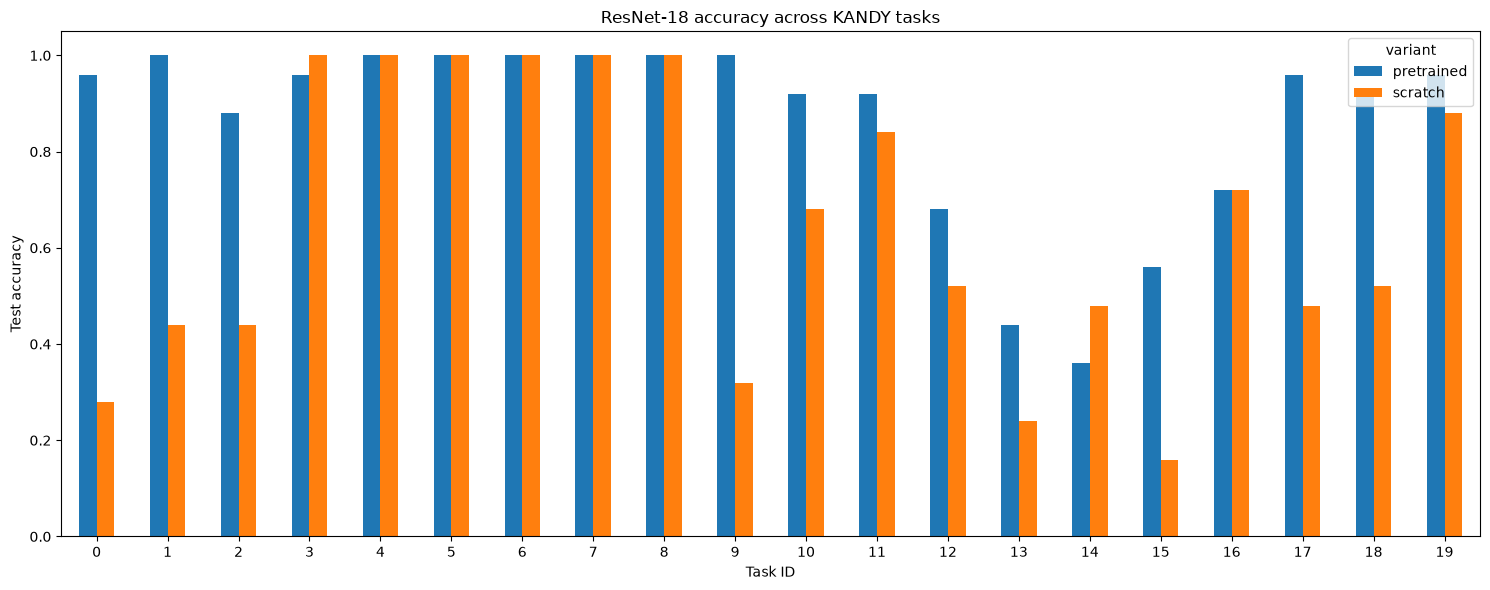

In [11]:
accuracy_plot = results_df.pivot(
    index="task_id",
    columns="variant",
    values="test_accuracy",
)

ax = accuracy_plot.plot(
    kind="bar",
    figsize=(15, 6),
)

ax.set_title(
    "ResNet-18 accuracy across KANDY tasks"
)
ax.set_xlabel("Task ID")
ax.set_ylabel("Test accuracy")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## F1 per task

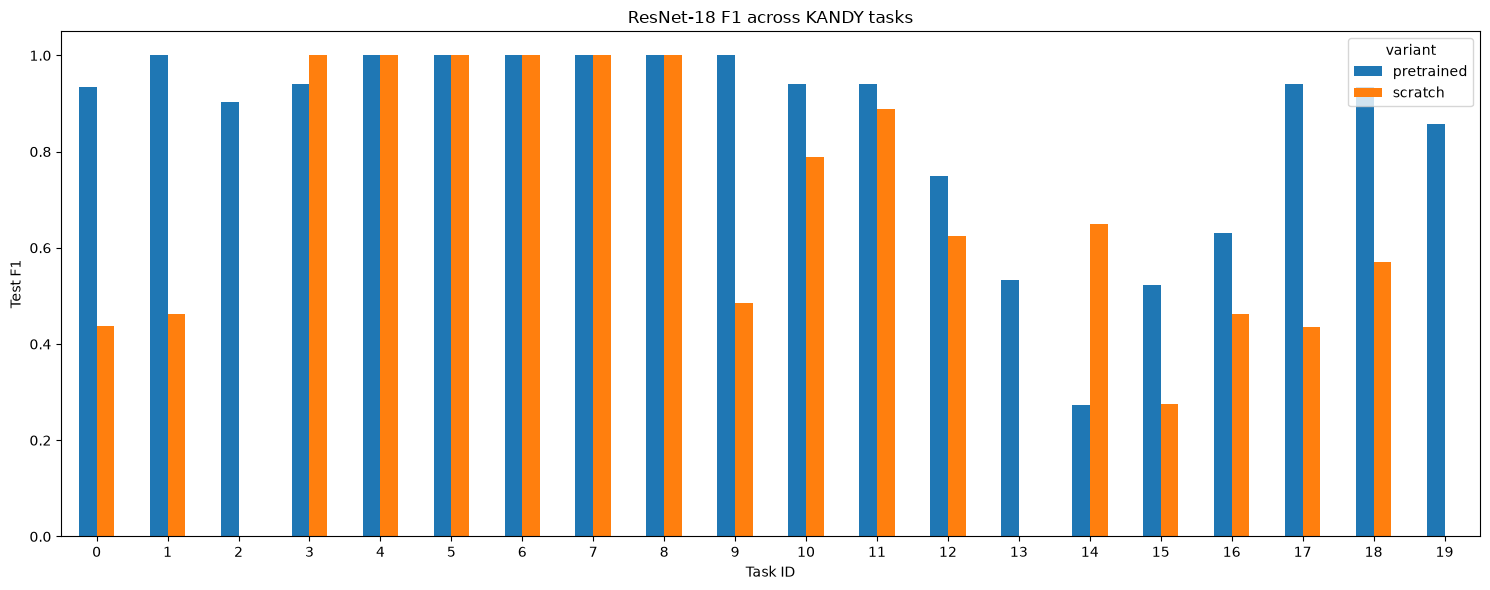

In [12]:
f1_plot = results_df.pivot(
    index="task_id",
    columns="variant",
    values="test_f1",
)

ax = f1_plot.plot(
    kind="bar",
    figsize=(15, 6),
)

ax.set_title(
    "ResNet-18 F1 across KANDY tasks"
)
ax.set_xlabel("Task ID")
ax.set_ylabel("Test F1")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Media e deviazione standard sulle task

In [13]:
summary = (
    results_df
    .groupby("variant")[
        [
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "training_time_seconds",
        ]
    ]
    .agg(["mean", "std"])
)

display(summary)


test_accuracy           test_precision           test_recall  \
                    mean       std           mean       std        mean   
variant                                                                   
pretrained         0.862  0.199568       0.837215  0.207153    0.884338   
scratch            0.650  0.295902       0.586297  0.380370    0.707034   

                       test_f1           training_time_seconds             
                 std      mean       std                  mean        std  
variant                                                                    
pretrained  0.212356  0.855056  0.205964             74.594310  23.599201  
scratch     0.373470  0.603975  0.353421             77.748118  41.729543

## Task di particolare interesse per l’analisi XAI

In [14]:
candidate = (
    results_df
    .groupby(["task_id", "task_name"])
    .agg(
        mean_f1=("test_f1", "mean"),
        min_f1=("test_f1", "min"),
        max_f1=("test_f1", "max"),
        max_errors=(
            ["fp", "fn"],
            lambda x: np.nan,
        ) if False else ("test_f1", "mean"),
    )
)

# Costruiamo separatamente il gap tra le due varianti.
f1_wide = results_df.pivot(
    index="task_id",
    columns="variant",
    values="test_f1",
)

candidate_df = pd.DataFrame({
    "task_id": TASK_IDS,
    "task_name": [
        TASK_NAMES[i] for i in TASK_IDS
    ],
    "pretrained_f1": f1_wide["pretrained"].values,
    "scratch_f1": f1_wide["scratch"].values,
})

candidate_df["absolute_f1_gap"] = (
    candidate_df["pretrained_f1"]
    - candidate_df["scratch_f1"]
).abs()

candidate_df["signed_f1_gap"] = (
    candidate_df["pretrained_f1"]
    - candidate_df["scratch_f1"]
)

display(
    candidate_df.sort_values(
        "absolute_f1_gap",
        ascending=False,
    )
)


,task_id,task_name,pretrained_f1,scratch_f1,absolute_f1_gap,signed_f1_gap
2,2,circle vs any,0.903226,0.000000,0.903226,0.903226
19,19,traffic light,0.857143,0.000000,0.857143,0.857143
1,1,square vs any,1.000000,0.461538,0.538462,0.538462
13,13,"triangle and square, same color",0.533333,0.000000,0.533333,0.533333
9,9,red triangle on the right,1.000000,0.484848,0.515152,0.515152
17,17,tower,0.941176,0.434783,0.506394,0.506394
0,0,triangle vs any,0.933333,0.437500,0.495833,0.495833
14,14,palindrome aba,0.272727,0.648649,0.375921,-0.375921
18,18,wagon,0.933333,0.571429,0.361905,0.361905
15,15,house,0.521739,0.275862,0.245877,0.245877


## Caso Task 19 — traffic light

Confrontiamo esplicitamente il caso che era già stato osservato manualmente.

In [17]:
display(
    results_df[
        results_df["task_id"] == 14
    ][
        [
            "task_id",
            "task_name",
            "variant",
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "tp",
            "tn",
            "fp",
            "fn",
        ]
    ]
)


,task_id,task_name,variant,test_accuracy,test_precision,test_recall,test_f1,tp,tn,fp,fn
28,14,palindrome aba,pretrained,0.36,0.30,0.25,0.272727,3,6,7,9
29,14,palindrome aba,scratch,0.48,0.48,1.00,0.648649,12,0,13,0


## Configurazione del benchmark

In [16]:
benchmark_config = {
    "experiment": "KANDY ResNet18 all-task benchmark",
    "seed": SEED,
    "device": str(DEVICE),
    "task_ids": TASK_IDS,
    "model_variants": MODEL_VARIANTS,
    "expected_experiments": (
        len(TASK_IDS) * len(MODEL_VARIANTS)
    ),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "results_csv": str(benchmark_csv),
}

config_path = (
    CNN_RESULTS_DIR
    / "cnn_benchmark_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        benchmark_config,
        f,
        indent=2,
    )

print("Saved:", config_path)


Saved: /home/cosimo/Downloads/kandy-xai/results/cnn_benchmark/cnn_benchmark_config.json


# Output finale

Il file principale è:

```text
cnn_benchmark_results.csv
```

e contiene **40 righe**, una per ogni coppia:

```text
(task_id, modello)
```